# Storage benchmark: what deduplication actually saves

Ancestree stores artifact bytes in a content-addressed chunk pool inside
`ancestree.db`. Three mechanisms reduce what lands on disk, and they stack:

1. **Node dedup.** A rerun producing identical content returns the existing
   node. Nothing new is stored at all.
2. **Chunk dedup (Layer 1).** Artifacts are split at content-defined
   boundaries and each distinct chunk is stored once, across every artifact
   in the store.
3. **Delta storage (Layer 2).** A chunk that resembles one already stored is
   kept as a zlib delta against it, when that beats compressing it alone.

Underneath all three, each stored chunk is zlib-compressed unless that makes
it bigger, in which case it is kept verbatim.

This notebook quantifies each layer separately and together, across file
types, file sizes and edit patterns, and accounts for the overhead the
database itself adds. Everything runs in a temp directory and is deleted at
the end.

In [1]:
import json
import platform
import shutil
import sqlite3
import sys
import tempfile
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ancestree
from ancestree.ingest.cdc import AVG_SIZE, LARGE_FILE_THRESHOLD, MAX_SIZE, MIN_SIZE

WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-storage-"))
MB = 1024 * 1024
KIND = {0: "zlib", 1: "delta", 2: "verbatim"}

print(f"ancestree {ancestree.__version__}")
print(f"python    {sys.version.split()[0]}")
print(f"platform  {platform.platform()}")
print(
    f"chunker   min {MIN_SIZE // 1024}K  avg {AVG_SIZE // 1024}K  "
    f"max {MAX_SIZE // 1024}K  large-file fallback at "
    f"{LARGE_FILE_THRESHOLD // MB}M"
)
print(f"workdir   {WORKDIR}")

ancestree 0.2.0
python    3.12.12
platform  macOS-26.5.1-arm64-arm-64bit
chunker   min 8K  avg 16K  max 256K  large-file fallback at 64M
workdir   /var/folders/xf/n_m7ztrx4x577r3935n_1m1w0000gn/T/ancestree-storage-3d9ky7qu


## Reading the numbers

`store.stats()` reports the two figures that matter. **Logical bytes** is
what your artifacts would occupy as plain files. **Stored bytes** is what the
chunk pool holds after dedup and compression. Their quotient is the dedup
ratio.

`database_bytes` is the honest third number: the file on disk, carrying the
node and metadata rows, the artifact-to-chunk recipes, the resemblance index
and every SQLite index alongside the payload. A benchmark quoting only the
chunk pool is flattering itself, so every table below reports both, and
`true_ratio` divides the logical size by the real file.

One correction is needed before those numbers mean anything.

In [2]:
def checkpoint(store):
    """Fold the write-ahead log back into ancestree.db.

    While a store is open, recently written bytes live in ``ancestree.db-wal``
    and are counted twice against the file on disk. Every storage figure here
    is taken after a checkpoint so it reflects the settled store rather than a
    mid-session artefact of WAL journalling.
    """
    conn = sqlite3.connect(store.root / "ancestree.db")
    try:
        conn.execute("PRAGMA wal_checkpoint(TRUNCATE)")
    finally:
        conn.close()


def report(store, label=""):
    """stats() plus the chunk encoding mix, as one flat dict."""
    checkpoint(store)
    stats = store.stats()
    kinds = {
        KIND[row["kind"]]: (row["n"], row["bytes"])
        for row in store.sql(
            "SELECT kind, count(*) AS n, SUM(LENGTH(data)) AS bytes "
            "FROM chunk GROUP BY kind"
        )
    }
    logical = stats["logical_bytes"]
    stored = stats["chunk_stored_bytes"]
    db = stats["database_bytes"]
    return {
        "label": label,
        "nodes": stats["nodes"],
        "artifacts": stats["artifacts"],
        "chunks": stats["chunks"],
        "logical_MB": logical / MB,
        "stored_MB": stored / MB,
        "db_MB": db / MB,
        "ratio": stats["dedup_ratio"],
        "true_ratio": round(logical / db, 3) if db else None,
        "zlib_chunks": kinds.get("zlib", (0, 0))[0],
        "delta_chunks": kinds.get("delta", (0, 0))[0],
        "verbatim_chunks": kinds.get("verbatim", (0, 0))[0],
    }


def show(rows, cols=None):
    frame = pd.DataFrame(rows)
    if cols:
        frame = frame[cols]
    print(frame.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    return frame

## The corpus

Eight payload types spanning what a real pipeline produces: text formats,
numeric arrays, a sparse array, and two payloads chosen to bracket the
extremes. `random` stands in for anything already compressed (PNG, parquet,
zip, `savez_compressed`); `repetitive` is the degenerate case where
content-defined chunking has nothing to find.

In [3]:
rng = np.random.default_rng(0)


def make_csv(n):
    rows = max(1, n // 22)
    return (
        pd.DataFrame(
            {
                "ts": np.arange(rows),
                "a": rng.normal(size=rows).round(4),
                "b": rng.normal(size=rows).round(4),
            }
        )
        .to_csv(index=False)
        .encode()
    )


def make_jsonl(n):
    rows = max(1, n // 78)
    return b"".join(
        json.dumps(
            {
                "id": i,
                "user": f"user_{i % 500}",
                "score": round(float(rng.random()), 6),
                "ok": bool(i % 3),
                "tag": "abcdefghij"[i % 10] * 8,
            }
        ).encode()
        + b"\n"
        for i in range(rows)
    )


def make_log(n):
    levels = ["INFO", "WARN", "ERROR", "DEBUG"]
    rows = max(1, n // 86)
    return b"".join(
        f"2026-07-25T12:{i % 60:02d}:{i % 60:02d}Z {levels[i % 4]:5} worker-{i % 16:02d} "
        f"processed batch {i} in {rng.random() * 100:.3f}ms\n".encode()
        for i in range(rows)
    )


def make_float64(n):
    return rng.normal(size=max(1, n // 8)).tobytes()


def make_int32(n):
    return rng.integers(0, 1000, size=max(1, n // 4), dtype=np.int32).tobytes()


def make_sparse(n):
    arr = np.zeros(max(1, n // 8))
    idx = rng.choice(arr.size, size=max(1, arr.size // 100), replace=False)
    arr[idx] = rng.normal(size=idx.size)
    return arr.tobytes()


def make_random(n):
    return rng.integers(0, 256, size=n, dtype=np.uint8).tobytes()


def make_repetitive(n):
    return (b"the quick brown fox jumps over the lazy dog. " * (n // 44 + 1))[:n]


GENERATORS = {
    "csv": make_csv,
    "jsonl": make_jsonl,
    "log": make_log,
    "float64": make_float64,
    "int32": make_int32,
    "sparse": make_sparse,
    "random": make_random,
    "repetitive": make_repetitive,
}

## 1. Compression alone, no duplicates

The floor: one artifact of each type, stored once, nothing to deduplicate
against. Whatever saving appears here is zlib doing its ordinary job on
individual chunks, and it tells you which of your file types the store can
help with at all.

In [4]:
print("One 8 MB artifact of each type, in its own store\n")
solo_rows = []
for name, gen in GENERATORS.items():
    payload = gen(8 * MB)
    store = ancestree.LineageStore(WORKDIR / f"solo_{name}", dedup=False)
    with store.create_node(step_type="solo") as node:
        (node / f"{name}.bin").write_bytes(payload)
        node.add_meta("type", name)
    row = report(store, name)
    row["whole_file_zlib"] = len(payload) / len(zlib.compress(payload, 6))
    solo_rows.append(row)
    store.close()

solo = show(
    solo_rows,
    [
        "label",
        "chunks",
        "logical_MB",
        "stored_MB",
        "ratio",
        "whole_file_zlib",
        "zlib_chunks",
        "verbatim_chunks",
    ],
)

One 8 MB artifact of each type, in its own store

     label  chunks  logical_MB  stored_MB   ratio  whole_file_zlib  zlib_chunks  verbatim_chunks
       csv     419       7.813      2.950   2.648            2.762          419                0
     jsonl     329       8.612      1.201   7.168            7.309          266                0
       log     409       6.585      1.100   5.986            7.330          409                0
   float64     434       8.000      7.698   1.039            1.041          434                0
     int32     408       8.000      3.786   2.113            2.238          408                0
    sparse      47       8.000      0.121  66.070           67.975           47                0
    random     437       8.000      8.000   1.000            1.000            0              437
repetitive      32       8.000      0.025 316.313          342.826           32                0


Two things worth reading off this table.

Chunk-wise compression tracks whole-file compression closely but not exactly:
compressing 16 KiB at a time forfeits the long-range matches a single stream
would find. That is the price of addressable chunks, and it is what buys
deduplication across artifacts.

The `verbatim_chunks` column is the store declining to compress. zlib
*inflates* data it cannot compress, so a chunk that does not shrink is kept
as-is: no cost on write and no pointless decompress on every read. For
already-compressed formats that is nearly every chunk.

A practical corollary: `np.savez` plus this store beats
`np.savez_compressed`, because the uncompressed form chunk-dedups across
versions and the compressed one never will.

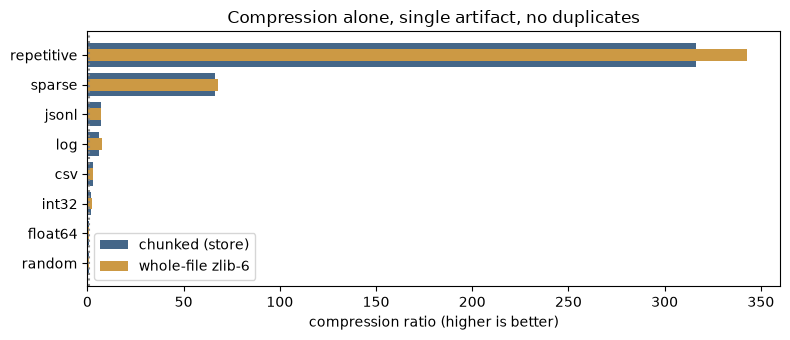

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
order = solo.sort_values("ratio", ascending=False)
ax.barh(order["label"], order["ratio"], color="#468", label="chunked (store)")
ax.barh(
    order["label"],
    order["whole_file_zlib"],
    height=0.4,
    color="#c94",
    label="whole-file zlib-6",
)
ax.axvline(1.0, color="#888", ls=":")
ax.set_xlabel("compression ratio (higher is better)")
ax.set_title("Compression alone, single artifact, no duplicates")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

## 2. Layer 1: exact chunk dedup

The same artifact written into ten separate nodes with `dedup=False`, so node
dedup cannot short-circuit it and every copy really goes through the write
path. Chunk dedup should mean the pool stops growing after the first.

In [6]:
print("Ten nodes, identical 8 MB artifact, node dedup off\n")
layer1_rows = []
for name in ["csv", "float64", "random"]:
    payload = GENERATORS[name](8 * MB)
    store = ancestree.LineageStore(WORKDIR / f"l1_{name}", dedup=False)
    for i in range(10):
        with store.create_node(step_type="copy") as node:
            (node / "data.bin").write_bytes(payload)
            node.add_meta("copy", i)
        if i in (0, 4, 9):
            row = report(store, f"{name} x{i + 1}")
            layer1_rows.append(row)
    store.close()

show(
    layer1_rows,
    ["label", "nodes", "chunks", "logical_MB", "stored_MB", "db_MB", "ratio"],
)

Ten nodes, identical 8 MB artifact, node dedup off

      label  nodes  chunks  logical_MB  stored_MB  db_MB  ratio
     csv x1      1     427       7.813      2.951  3.902  2.648
     csv x5      5     427      39.066      2.951  4.246 13.240
    csv x10     10     427      78.132      2.951  4.672 26.480
 float64 x1      1     434       8.000      7.697  8.578  1.039
 float64 x5      5     434      40.000      7.697  8.926  5.196
float64 x10     10     434      80.000      7.697  9.359 10.393
  random x1      1     430       8.000      8.000  8.871  1.000
  random x5      5     430      40.000      8.000  9.203  5.000
 random x10     10     430      80.000      8.000  9.637 10.000


,label,nodes,chunks,logical_MB,stored_MB,db_MB,ratio
0,csv x1,1,427,7.813183,2.950642,3.902344,2.648
1,csv x5,5,427,39.065914,2.950642,4.246094,13.240
2,csv x10,10,427,78.131828,2.950642,4.671875,26.480
3,float64 x1,1,434,8.000000,7.697495,8.578125,1.039
4,float64 x5,5,434,40.000000,7.697495,8.925781,5.196
5,float64 x10,10,434,80.000000,7.697495,9.359375,10.393
6,random x1,1,430,8.000000,8.000000,8.871094,1.000
7,random x5,5,430,40.000000,8.000000,9.203125,5.000
8,random x10,10,430,80.000000,8.000000,9.636719,10.000


The chunk count is flat across copies two through ten: every chunk after the
first artifact is already in the pool and the insert is ignored. Ten copies
of an incompressible 8 MB file cost 8 MB, not 80 MB, and that holds even for
`random`, where compression can do nothing at all. This is the layer that
matters most for the way people actually work: copy a dataset into three
branches and only one of them is stored.

## 3. Node dedup: the layer above

With `dedup=True` (the default), an identical rerun does not create a node at
all. Same experiment, default policy.

In [7]:
print("Ten identical reruns, node dedup ON (the default)\n")
payload = GENERATORS["csv"](8 * MB)
store = ancestree.LineageStore(WORKDIR / "node_dedup", dedup=True)
for i in range(10):
    with store.create_node(step_type="rerun") as node:
        (node / "data.csv").write_bytes(payload)
        node.add_meta("params", "fixed")
final = report(store, "10 identical reruns")
store.close()
print(f"  nodes in store:     {final['nodes']}  (of 10 attempted)")
print(f"  artifacts:          {final['artifacts']}")
print(f"  stored:             {final['stored_MB']:.2f} MB")
print("\n  Reruns collapse onto the node that already exists. Change any input,")
print("  any metadata value or any artifact byte and you get a distinct node.")
print("  Failed runs never merge. Pass dedup=False to record every run.")

Ten identical reruns, node dedup ON (the default)

  nodes in store:     1  (of 10 attempted)
  artifacts:          1
  stored:             2.95 MB

  Reruns collapse onto the node that already exists. Change any input,
  any metadata value or any artifact byte and you get a distinct node.
  Failed runs never merge. Pass dedup=False to record every run.


## 4. Layer 2: delta storage against near-duplicates

The hard case, and the one Layer 2 exists for. Twelve successive revisions of
an artifact with about 1% of bytes edited each time, scattered. Content-defined
boundaries survive the edits, so the chunks stay aligned, but almost every
chunk differs by a byte or two. Exact dedup shares nothing. Delta storage has
to earn its keep.

In [8]:
def revisions(policy, kind, versions=12, size=4 * MB, edit=0.01, mode="overwrite"):
    """Successive revisions of one artifact, returning per-version storage."""
    store = ancestree.LineageStore(
        WORKDIR / f"rev_{kind}_{mode}_{int(policy)}", chunk=policy, dedup=False
    )
    payload = bytearray(GENERATORS[kind](size))
    local = np.random.default_rng(7)
    growth = []
    for v in range(versions):
        count = int(len(payload) * edit)
        if mode == "overwrite":
            for pos in local.integers(0, len(payload), size=count):
                payload[int(pos)] = int(local.integers(0, 256))
        elif mode == "insert":
            at = int(local.integers(0, len(payload)))
            payload[at:at] = bytes(local.integers(0, 256, size=count, dtype=np.uint8))
        elif mode == "delete":
            at = int(local.integers(0, len(payload) - count))
            del payload[at : at + count]
        elif mode == "append":
            payload += bytes(local.integers(0, 256, size=count, dtype=np.uint8))
        with store.create_node(step_type="rev") as node:
            (node / "data.bin").write_bytes(bytes(payload))
            node.add_meta("v", v)
        growth.append(store.stats()["chunk_stored_bytes"] / MB)
    row = report(store, f"{kind} {'layer 1+2' if policy else 'layer 1 only'}")
    store.close()
    return row, growth


print("Twelve revisions, ~1% scattered in-place edits\n")
l2_rows, curves = [], {}
for kind in ["csv", "float64"]:
    for policy in [False, True]:
        row, growth = revisions(policy, kind)
        l2_rows.append(row)
        curves[(kind, policy)] = growth

show(
    l2_rows,
    [
        "label",
        "chunks",
        "logical_MB",
        "stored_MB",
        "db_MB",
        "ratio",
        "zlib_chunks",
        "delta_chunks",
        "verbatim_chunks",
    ],
)

for kind in ["csv", "float64"]:
    off = next(r for r in l2_rows if r["label"] == f"{kind} layer 1 only")
    on = next(r for r in l2_rows if r["label"] == f"{kind} layer 1+2")
    print(
        f"\n  {kind}: Layer 2 stores {off['stored_MB'] / on['stored_MB']:.2f}x less "
        f"({off['stored_MB']:.1f} MB -> {on['stored_MB']:.1f} MB), "
        f"{on['delta_chunks']} of {on['chunks']} chunks kept as deltas"
    )

Twelve revisions, ~1% scattered in-place edits

               label  chunks  logical_MB  stored_MB  db_MB  ratio  zlib_chunks  delta_chunks  verbatim_chunks
    csv layer 1 only    2557      46.246     22.401 24.957  2.064         2557             0                0
       csv layer 1+2    2545      46.253     11.540 14.902  4.008          864          1681                0
float64 layer 1 only    2579      48.000     46.385 49.211  1.035         2579             0                0
   float64 layer 1+2    2688      48.000     21.226 24.750  2.261          935          1753                0

  csv: Layer 2 stores 1.94x less (22.4 MB -> 11.5 MB), 1681 of 2545 chunks kept as deltas

  float64: Layer 2 stores 2.19x less (46.4 MB -> 21.2 MB), 1753 of 2688 chunks kept as deltas


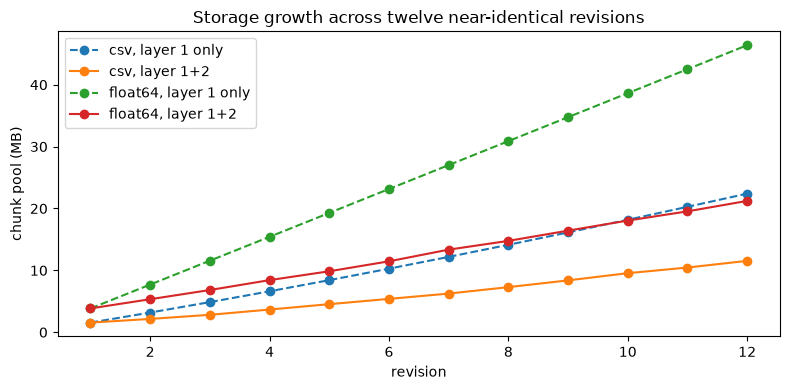

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for (kind, policy), growth in curves.items():
    ax.plot(
        range(1, len(growth) + 1),
        growth,
        "o-" if policy else "o--",
        label=f"{kind}, {'layer 1+2' if policy else 'layer 1 only'}",
    )
ax.set_xlabel("revision")
ax.set_ylabel("chunk pool (MB)")
ax.set_title("Storage growth across twelve near-identical revisions")
ax.legend()
fig.tight_layout()
plt.show()

The first revision costs full price in both cases: there is nothing to
deduplicate or delta against yet. What separates the lines is the slope.
Without Layer 2 every revision adds most of an artifact. With it, each
revision adds roughly the bytes that actually changed.

Note the `delta_chunks` count against `zlib_chunks`. A delta is only kept
when it beats plain compression by a margin, and only non-delta chunks may
serve as bases (depth is capped at 1). Taking every marginal delta measurably
*costs* storage, because each one removes a candidate base from the
resemblance index.

### Edit patterns

Four ways an artifact changes between revisions. Scattered overwrites touch
1% of bytes spread across the whole file; the other three concentrate the
same volume at one point, either shifting everything after it (insert,
delete) or not (append).

In [10]:
print("Twelve revisions of a 4 MB CSV, by edit pattern\n")
mode_rows = []
for mode in ["overwrite", "insert", "delete", "append"]:
    row, _ = revisions(True, "csv", mode=mode)
    row["label"] = mode
    mode_rows.append(row)

show(mode_rows, ["label", "chunks", "logical_MB", "stored_MB", "ratio", "delta_chunks"])

Twelve revisions of a 4 MB CSV, by edit pattern

    label  chunks  logical_MB  stored_MB  ratio  delta_chunks
overwrite    5083      92.493     23.479  3.939          3266
   insert     268      49.368      2.129 23.188             7
   delete     239      43.345      1.650 26.272             7
   append     246      49.361      1.964 25.135            10


,label,chunks,logical_MB,stored_MB,ratio,delta_chunks
0,overwrite,5083,92.492752,23.479478,3.939,3266
1,insert,268,49.367670,2.128973,23.188,7
2,delete,239,43.344887,1.649843,26.272,7
3,append,246,49.360801,1.963837,25.135,10


The three concentrated patterns deduplicate almost perfectly and barely use
Layer 2 at all: the edit invalidates the handful of chunks around it, the
boundary algorithm re-syncs within a chunk or two, and every chunk after that
hashes identically to the previous revision. That re-sync is the whole point
of content-defined chunking, and `insert` and `delete` are the proof: a
fixed-block scheme would shift every block after the edit point and share
nothing beyond it.

Scattered overwrites are the genuinely hard case and the one Layer 2 exists
for. Spreading the same 1% across the whole file leaves almost every chunk
differing by a byte or two, so exact dedup finds nothing and the ratio rests
on deltas instead: note the delta count against the other three rows. It
still lands at a useful ratio, but it earns it the expensive way.

## 5. File size

Dedup ratio against artifact size, from below the minimum chunk size to
across the 64 MiB large-file threshold, where the chunker stops looking for
content-defined boundaries and cuts at fixed offsets instead.

In [11]:
print("Three revisions of one CSV, across artifact sizes\n")
size_rows = []
for kb in [16, 64, 256, 1024, 4096, 16384, 73728]:
    size = kb * 1024
    store = ancestree.LineageStore(WORKDIR / f"size_{kb}", dedup=False)
    payload = bytearray(make_csv(size))
    local = np.random.default_rng(3)
    for v in range(3):
        for pos in local.integers(0, len(payload), size=max(1, len(payload) // 100)):
            payload[int(pos)] = ord("0") + int(local.integers(0, 10))
        with store.create_node(step_type="rev") as node:
            (node / "data.csv").write_bytes(bytes(payload))
            node.add_meta("v", v)
    row = report(store, f"{size / MB:.3f} MB")
    row["MB"] = size / MB
    row["chunks_per_artifact"] = row["chunks"] / 3
    row["path"] = "fixed cuts" if size >= LARGE_FILE_THRESHOLD else "CDC"
    size_rows.append(row)
    store.close()

show(
    size_rows,
    [
        "label",
        "MB",
        "path",
        "chunks",
        "logical_MB",
        "stored_MB",
        "db_MB",
        "ratio",
        "true_ratio",
        "delta_chunks",
    ],
)

Three revisions of one CSV, across artifact sizes

    label     MB       path  chunks  logical_MB  stored_MB  db_MB  ratio  true_ratio  delta_chunks
 0.016 MB  0.016        CDC       6       0.040      0.007  0.121  5.492       0.328             4
 0.062 MB  0.062        CDC       9       0.165      0.029  0.145  5.701       1.143             6
 0.250 MB  0.250        CDC      37       0.676      0.166  0.316  4.073       2.138            18
 1.000 MB  1.000        CDC     150       2.802      0.702  1.016  3.992       2.759            66
 4.000 MB  4.000        CDC     626      11.561      2.859  3.840  4.044       3.011           278
16.000 MB 16.000        CDC    2571      47.196     10.942 14.605  4.313       3.231          1217
72.000 MB 72.000 fixed cuts     882     220.459     81.363 83.227  2.710       2.649             0


,label,MB,path,chunks,logical_MB,stored_MB,db_MB,ratio,true_ratio,delta_chunks
0,0.016 MB,0.015625,CDC,6,0.039757,0.007238,0.121094,5.492,0.328,4
1,0.062 MB,0.062500,CDC,9,0.165210,0.028980,0.144531,5.701,1.143,6
2,0.250 MB,0.250000,CDC,37,0.676463,0.166098,0.316406,4.073,2.138,18
3,1.000 MB,1.000000,CDC,150,2.802235,0.701957,1.015625,3.992,2.759,66
4,4.000 MB,4.000000,CDC,626,11.561056,2.859052,3.839844,4.044,3.011,278
5,16.000 MB,16.000000,CDC,2571,47.196399,10.941926,14.605469,4.313,3.231,1217
6,72.000 MB,72.000000,fixed cuts,882,220.459488,81.363389,83.226562,2.710,2.649,0


The chunk pool ratio holds up even on small files, but it is the wrong column
to read there. Compare it to `true_ratio`, which divides by the actual
database file. On a 16 KiB artifact the pool is tiny and the file is not: a
database has a page size, a schema, and index pages that exist whether you
store anything or not, so the fixed cost swamps the payload and the store
is larger than the plain files would be.

Deduplication is a megabyte-scale mechanism. The two ratios converge as the
payload grows past the fixed cost, and by a few megabytes the pool number is
a fair summary of the file.

Above 64 MiB the chunker switches to fixed 256 KiB cuts to keep huge ingests
at C speed. Exact whole-file and repeated-content dedup still work; the
shift-resilience does not, so an inserted byte near the front of a 100 MB
file rewrites the whole thing. That trade is deliberate and documented.

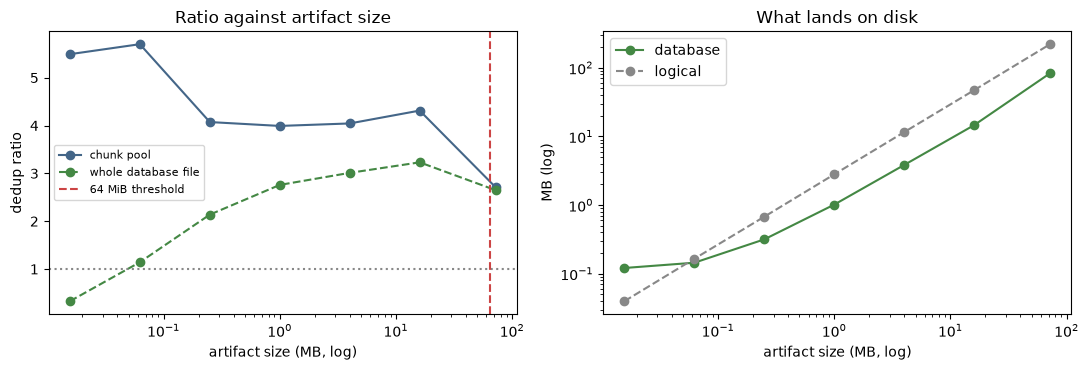

In [12]:
size_df = pd.DataFrame(size_rows)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.semilogx(size_df["MB"], size_df["ratio"], "o-", color="#468", label="chunk pool")
a1.semilogx(
    size_df["MB"],
    size_df["true_ratio"],
    "o--",
    color="#484",
    label="whole database file",
)
a1.axhline(1.0, color="#888", ls=":")
a1.axvline(LARGE_FILE_THRESHOLD / MB, color="#c44", ls="--", label="64 MiB threshold")
a1.set_xlabel("artifact size (MB, log)")
a1.set_ylabel("dedup ratio")
a1.set_title("Ratio against artifact size")
a1.legend(fontsize=8)
a2.loglog(size_df["MB"], size_df["db_MB"], "o-", color="#484", label="database")
a2.loglog(size_df["MB"], size_df["logical_MB"], "o--", color="#888", label="logical")
a2.set_xlabel("artifact size (MB, log)")
a2.set_ylabel("MB (log)")
a2.set_title("What lands on disk")
a2.legend()
fig.tight_layout()
plt.show()

## 6. Overhead: what the database costs on top

Everything above quoted the chunk pool. The file on disk also carries node
rows, metadata rows, the artifact-to-chunk recipes, the resemblance index and
every SQLite index. That overhead is what you actually pay.

In [13]:
print("Where the database file goes (12-revision CSV store)\n")
store = ancestree.LineageStore(WORKDIR / "overhead", dedup=False)
payload = bytearray(make_csv(4 * MB))
local = np.random.default_rng(11)
for v in range(12):
    for pos in local.integers(0, len(payload), size=len(payload) // 100):
        payload[int(pos)] = ord("0") + int(local.integers(0, 10))
    with store.create_node(step_type="rev") as node:
        (node / "data.csv").write_bytes(bytes(payload))
        node.add_meta("v", v)
        node.add_meta("accuracy", round(float(rng.random()), 4))
store.close()
store = ancestree.LineageStore(WORKDIR / "overhead", dedup=False)

pages = store.sql(
    "SELECT name, SUM(pgsize) AS bytes FROM dbstat GROUP BY name ORDER BY bytes DESC"
)
total = sum(r["bytes"] for r in pages)
for row in pages:
    if row["bytes"] > total / 500:
        print(
            f"  {row['name']:<24} {row['bytes'] / 1024:9.1f} KiB "
            f"{row['bytes'] / total:6.1%}"
        )
over = report(store, "overhead")
print(f"\n  chunk payload      {over['stored_MB']:.2f} MB")
print(f"  database file      {over['db_MB']:.2f} MB")
print(
    f"  overhead           {over['db_MB'] - over['stored_MB']:.2f} MB "
    f"({(over['db_MB'] / over['stored_MB'] - 1):.0%} on top of the payload)"
)
print(f"  ratio on the pool  {over['ratio']}")
print(f"  ratio on the file  {over['true_ratio']}   <- the honest number")
store.close()

Where the database file goes (12-revision CSV store)

  chunk                      12404.0 KiB  88.9%
  sqlite_autoindex_chunk_feature_1     352.0 KiB   2.5%
  chunk_feature                312.0 KiB   2.2%
  artifact_chunk               240.0 KiB   1.7%
  sqlite_autoindex_chunk_1     204.0 KiB   1.5%
  idx_ac_digest                204.0 KiB   1.5%
  sqlite_autoindex_artifact_chunk_1      92.0 KiB   0.7%
  idx_feature                   68.0 KiB   0.5%

  chunk payload      10.27 MB
  database file      13.64 MB
  overhead           3.38 MB (33% on top of the payload)
  ratio on the pool  4.504
  ratio on the file  3.389   <- the honest number


The resemblance index (`chunk_feature`) is the largest non-payload consumer,
and it is what makes Layer 2 possible: a few rows per chunk to find delta
bases without comparing every chunk to every other. On a store dominated by
artifacts the overhead is a small percentage. On a metadata-only store there
is no payload at all, and the file is entirely index.

### Metadata-only nodes

Most nodes in a real pipeline hold no artifacts. This is what they cost.

In [14]:
store = ancestree.LineageStore(WORKDIR / "meta_only")
for i in range(2000):
    with store.create_node(step_type="step") as node:
        node.add_meta("run_id", i)
        node.add_meta("accuracy", round(float(rng.random()), 4))
        node.add_meta("dataset", f"ds_{i % 25}")
meta_stats = store.stats()
store.close()
db_bytes = meta_stats["database_bytes"]
print("  2000 nodes, 3 metadata entries each")
print(f"  database:          {db_bytes / MB:.2f} MB")
print(f"  per node:          {db_bytes / 2000:.0f} bytes")
print(
    f"\n  A million such nodes would be roughly {db_bytes / 2000 * 1e6 / MB / 1024:.1f} GB."
)
print("  Provenance (user, platform, python, git commit/branch/dirty) is the")
print("  bulk of it and is recorded on every node.")

  2000 nodes, 3 metadata entries each
  database:          5.41 MB
  per node:          2834 bytes

  A million such nodes would be roughly 2.6 GB.
  Provenance (user, platform, python, git commit/branch/dirty) is the
  bulk of it and is recorded on every node.


## 7. The headline: a realistic mixed corpus

Six file types, six revisions each, roughly 1% of bytes edited per revision:
60% overwrites, 20% insertions, 20% deletions, so shift-resilience is
genuinely exercised rather than assumed.

This is the same shape of corpus behind the 2.6x figure in the README and
`RESULTS.md`, and it lands higher here. The difference is where the edits
fall: that corpus scatters insertions and deletions as well as overwrites,
while this one applies each insertion and deletion at a single point, which
section 4 showed is by far the easier case. Take the README's number as the
conservative one. The point of this table is not the headline but the
comparison between the three rows.


In [15]:
def evolve(payload, local, fraction=0.01):
    data = bytearray(payload)
    count = int(len(data) * fraction)
    for pos in local.integers(0, len(data), size=int(count * 0.6)):
        data[int(pos)] = int(local.integers(0, 256))
    at = int(local.integers(0, len(data)))
    data[at:at] = bytes(local.integers(0, 256, size=int(count * 0.2), dtype=np.uint8))
    at = int(local.integers(0, len(data) - int(count * 0.2) - 1))
    del data[at : at + int(count * 0.2)]
    return bytes(data)


def corpus(dedup, chunk, label):
    store = ancestree.LineageStore(
        WORKDIR / f"corpus_{label}", dedup=dedup, chunk=chunk
    )
    kinds = ["csv", "jsonl", "log", "float64", "int32", "random"]
    payloads = {k: GENERATORS[k](2 * MB) for k in kinds}
    local = np.random.default_rng(5)
    parent = None
    for v in range(6):
        with store.create_node(step_type="version", parent=parent) as node:
            for k in kinds:
                payloads[k] = evolve(payloads[k], local)
                (node / f"{k}.bin").write_bytes(payloads[k])
            node.add_meta("version", v)
        parent = node.node_id
    row = report(store, label)
    store.close()
    return row


print("Six file types x six revisions, ~1% edits per revision\n")
policy_rows = [
    corpus(False, False, "chunk=False (layer 1 only)"),
    corpus(False, True, "chunk=True  (the default)"),
    corpus(True, True, "chunk=True, dedup=True"),
]
show(
    policy_rows,
    [
        "label",
        "nodes",
        "chunks",
        "logical_MB",
        "stored_MB",
        "db_MB",
        "ratio",
        "true_ratio",
        "delta_chunks",
    ],
)

best = policy_rows[1]
worst = policy_rows[0]
print(f"\n  Default policy stores {best['ratio']:.2f}x less than the logical size,")
print(f"  {worst['stored_MB'] / best['stored_MB']:.2f}x better than Layer 1 alone.")
print(f"  Counting the whole database file, still {best['true_ratio']:.2f}x.")

Six file types x six revisions, ~1% edits per revision

                     label  nodes  chunks  logical_MB  stored_MB  db_MB  ratio  true_ratio  delta_chunks
chunk=False (layer 1 only)      6    3753      69.958     39.515 43.367  1.770       1.613             0
 chunk=True  (the default)      6    3759      69.956     17.815 22.363  3.927       3.128          2271
    chunk=True, dedup=True      6    3730      69.960     18.121 22.715  3.861       3.080          2184

  Default policy stores 3.93x less than the logical size,
  2.22x better than Layer 1 alone.
  Counting the whole database file, still 3.13x.


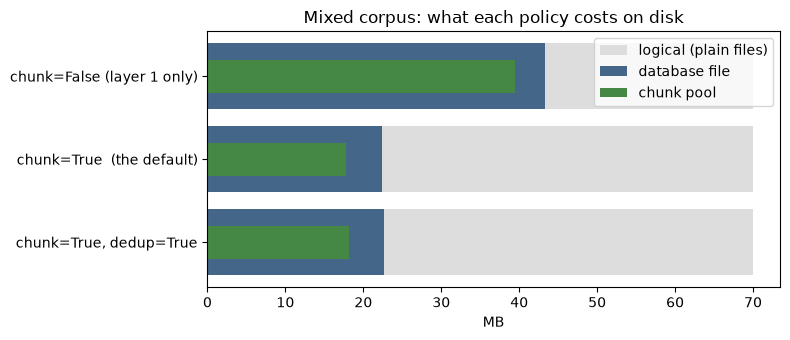

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = [r["label"] for r in policy_rows]
ax.barh(
    labels,
    [r["logical_MB"] for r in policy_rows],
    color="#ddd",
    label="logical (plain files)",
)
ax.barh(labels, [r["db_MB"] for r in policy_rows], color="#468", label="database file")
ax.barh(
    labels,
    [r["stored_MB"] for r in policy_rows],
    height=0.4,
    color="#484",
    label="chunk pool",
)
ax.set_xlabel("MB")
ax.set_title("Mixed corpus: what each policy costs on disk")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

## 8. Reclaiming space

Deleting a branch with `prune(dry_run=False)` removes its nodes and then
compacts: chunks no surviving artifact references are dropped and the pages
are returned to the OS. A delta base still in use survives even if its own
node is gone.

In [17]:
print("Prune and compact\n")
store = ancestree.LineageStore(WORKDIR / "prune", dedup=False)
root_ids = []
for branch in range(4):
    parent = None
    for v in range(4):
        with store.create_node(step_type="rev", parent=parent) as node:
            (node / "data.bin").write_bytes(GENERATORS["float64"](2 * MB))
            node.add_meta("branch", branch)
            node.add_meta("v", v)
        parent = node.node_id
        if v == 0:
            root_ids.append(node.node_id)

before = report(store, "before")
doomed = store.prune(root_ids[0])
print(f"  dry run: {len(doomed)} nodes would be deleted (nothing changed yet)")
after_dry = report(store, "after dry run")
store.prune(root_ids[0], dry_run=False)
after = report(store, "after prune")
show(
    [before, after_dry, after],
    ["label", "nodes", "chunks", "logical_MB", "stored_MB", "db_MB"],
)
print(f"\n  Reclaimed {before['db_MB'] - after['db_MB']:.2f} MB of database file.")
print("  The file shrinks in place. There is no undo: after compaction the")
print("  bytes are gone, not merely unreferenced.")
store.close()

Prune and compact

  dry run: 4 nodes would be deleted (nothing changed yet)
        label  nodes  chunks  logical_MB  stored_MB  db_MB
       before     16    1730      32.000     30.792 33.992
after dry run     16    1730      32.000     30.792 33.992
  after prune     12    1304      24.000     23.094 25.777

  Reclaimed 8.21 MB of database file.
  The file shrinks in place. There is no undo: after compaction the
  bytes are gone, not merely unreferenced.


## Summary

What to expect, by situation.

In [18]:
print("Storage, by what you are doing\n")
print("  Rerunning a step unchanged        nothing stored (node dedup)")
print("  Copying an artifact into branches  stored once (layer 1)")
print("  Iterating on a large artifact      ~the changed bytes (layer 2)")
print("  Already-compressed formats         stored verbatim, no ratio, no loss")
print("  Files under 8 KiB                  one chunk, overhead dominates")
print("  Files over 64 MiB                  fixed cuts, exact dedup only")
print()
print(
    f"  Mixed realistic corpus             {best['ratio']:.2f}x on the pool, "
    f"{best['true_ratio']:.2f}x on the file"
)
print(f"  Metadata-only node                 ~{db_bytes / 2000:.0f} bytes")
print()
print("  Run store.stats() against your own data. The ratio depends entirely")
print("  on what you produce and how much of it repeats.")

Storage, by what you are doing

  Rerunning a step unchanged        nothing stored (node dedup)
  Copying an artifact into branches  stored once (layer 1)
  Iterating on a large artifact      ~the changed bytes (layer 2)
  Already-compressed formats         stored verbatim, no ratio, no loss
  Files under 8 KiB                  one chunk, overhead dominates
  Files over 64 MiB                  fixed cuts, exact dedup only

  Mixed realistic corpus             3.93x on the pool, 3.13x on the file
  Metadata-only node                 ~2834 bytes

  Run store.stats() against your own data. The ratio depends entirely
  on what you produce and how much of it repeats.


## Clean up

In [19]:
shutil.rmtree(WORKDIR, ignore_errors=True)
print("done")

done
